Shape of X: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]


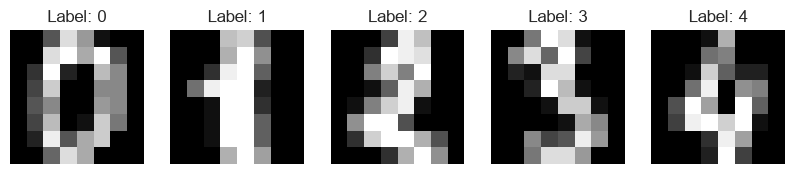


--- Manual K search ---
K=1: Accuracy = 0.9667
K=2: Accuracy = 0.9667
K=3: Accuracy = 0.9667
K=4: Accuracy = 0.9667
K=5: Accuracy = 0.9639
K=6: Accuracy = 0.9583
K=7: Accuracy = 0.9667
K=8: Accuracy = 0.9667
K=9: Accuracy = 0.9639
K=10: Accuracy = 0.9611
K=11: Accuracy = 0.9639
K=12: Accuracy = 0.9667
K=13: Accuracy = 0.9694
K=14: Accuracy = 0.9583
K=15: Accuracy = 0.9556
K=16: Accuracy = 0.9500
K=17: Accuracy = 0.9472
K=18: Accuracy = 0.9444
K=19: Accuracy = 0.9361
K=20: Accuracy = 0.9417

Best K (manual search): 13 with accuracy 0.9694


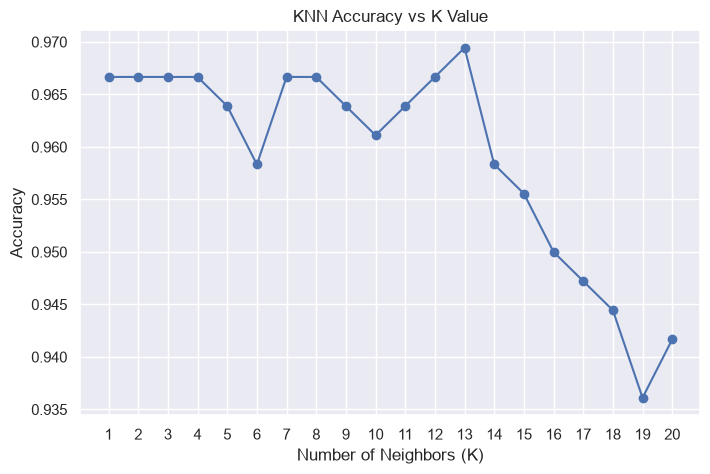


--- GridSearchCV search ---
Best K (GridSearchCV): 1
Best cross-validation score: 0.9756339527680989

Final Test Accuracy with K=1: 0.9667


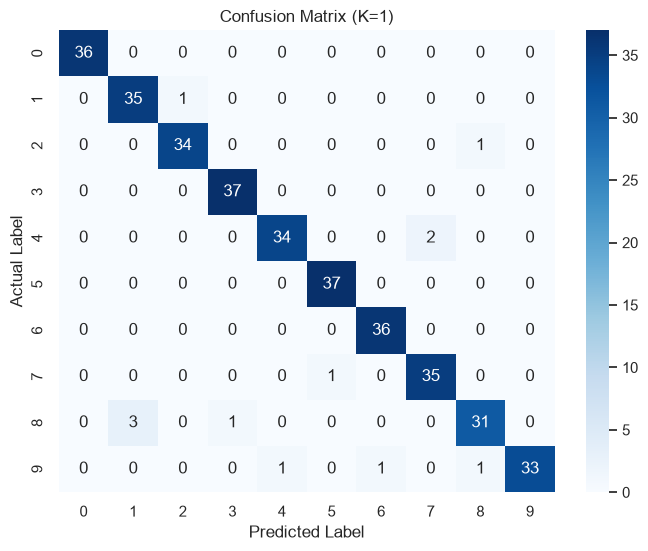


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       0.97      0.97      0.97        35
           3       0.97      1.00      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



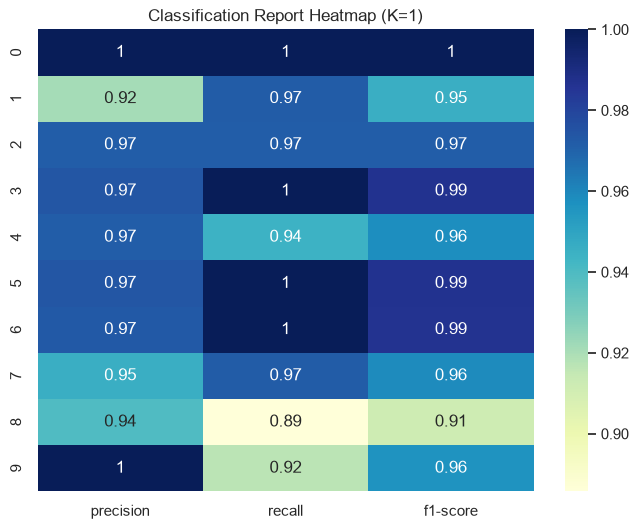

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

sns.set()

# 1. Load the dataset
digits = load_digits()
X = digits.data      # 64 features (8x8 pixel values flattened)
y = digits.target    # labels 0-9

print("Shape of X:", X.shape)
print("Classes:", np.unique(y))

# Quick look at a few sample digits
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off')
plt.show()

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features (important for KNN since it's distance-based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4a. METHOD 1: Manually try different values of K
print("\n--- Manual K search ---")
k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    scores.append(score)
    print(f"K={k}: Accuracy = {score:.4f}")

best_k_manual = k_values[np.argmax(scores)]
print(f"\nBest K (manual search): {best_k_manual} with accuracy {max(scores):.4f}")

# Plot accuracy vs K
plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# 4b. METHOD 2: GridSearchCV to find the best K
print("\n--- GridSearchCV search ---")
param_grid = {'n_neighbors': list(range(1, 21))}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train_scaled, y_train)

print("Best K (GridSearchCV):", grid_search.best_params_['n_neighbors'])
print("Best cross-validation score:", grid_search.best_score_)

# 5. Train final model using the best K found
best_k = grid_search.best_params_['n_neighbors']
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

test_accuracy = final_knn.score(X_test_scaled, y_test)
print(f"\nFinal Test Accuracy with K={best_k}: {test_accuracy:.4f}")

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()

# 7. Plot Classification Report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Visualize the classification report as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    report_df.iloc[:-3, :-1],   # exclude support column & accuracy/avg rows for cleaner heatmap
    annot=True,
    cmap='YlGnBu'
)
plt.title(f"Classification Report Heatmap (K={best_k})")
plt.show()